# Week 1 — Run it, then discover a real truth yourself

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MAhmadMakhdoom/flyrank-ml-internship/blob/main/notebooks/01_first_look_and_discovery.ipynb?flush_cache=true)

By the end of this notebook you will have:
1. **Run a real ML pipeline** on real (anonymized) search data and watched a learned model beat a hand-written rule.
2. **Rediscovered a real finding yourself** in ~10 lines of pandas.

No prior ML needed. Everything runs on the small anonymized dataset that ships with this repo — no credentials, no private data.

## 0. Setup (Colab or local)
On Colab this clones the repo and installs requirements. Locally it just moves to the repo root.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # find the repo root from wherever this kernel started
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

Working dir: /content/flyrank-ml-internship-starter
Starter data found. You're ready.


## 1. Run the whole pipeline

This runs `scripts/run_all.py`: prepare features → baseline rule → train 3 models → evaluate → PDF.
It takes ~1 minute on the 30,000-row sample.

In [2]:
# Watch it work — each of the 5 steps prints live as it runs (~1 minute total).
!{sys.executable} scripts/run_all.py



▶ Step 1/5 — Prepare features — clean the data, build the feature vector, define the label
Prepared 30,000 rows from 30,000 raw rows
Wrote /content/flyrank-ml-internship-starter/data/processed/refresh_feature_vector.csv

▶ Step 2/5 — Baseline — a transparent hand-written rule to beat
Wrote baseline queue: /content/flyrank-ml-internship-starter/data/processed/baseline_refresh_queue.csv
Top-50 declining rate (full data, not the evaluated holdout Precision@50): 0.340

▶ Step 3/5 — Train — logistic regression, decision tree, random forest (client-holdout split)
Trained 3 models on 30,000 rows
Split strategy: client_holdout
Best model: random_forest
Wrote predictions: /content/flyrank-ml-internship-starter/data/processed/model_predictions.csv
Wrote model results: /content/flyrank-ml-internship-starter/outputs/model_results.json

▶ Step 4/5 — Evaluate — ranked refresh queue, charts, and the Markdown report
Wrote final refresh queue: /content/flyrank-ml-internship-starter/outputs/refresh_que

### What just happened?
The pipeline ranked every page for "refresh review" two ways: a **hand-written rule baseline** and a **learned model**. Let's compare them on **Precision@50** — of the top 50 pages each says to fix first, how many are actually declining?

In [3]:
import json
res = json.load(open("outputs/model_results.json"))

base = res["baseline"]["baseline_precision_at_50"]
rf   = res["models"]["random_forest"]["precision_at_50"]

print(f"Hand-written rule  Precision@50: {base:.3f}   (~{round(base*50)} of the top 50 right)")
print(f"Random forest      Precision@50: {rf:.3f}   (~{round(rf*50)} of the top 50 right)")
print(f"\nThe learned model roughly {rf/base:.1f}x the rule on this metric.")
print("Validation split used:", res["split_strategy"], "(pages from a client are never in both train and test)")

Hand-written rule  Precision@50: 0.240   (~12 of the top 50 right)
Random forest      Precision@50: 0.740   (~37 of the top 50 right)

The learned model roughly 3.1x the rule on this metric.
Validation split used: client_holdout (pages from a client are never in both train and test)


You just ran a real ML system on real search data and saw a learned ranking beat a fixed rule. Now open `outputs/model_report.md` and skim it — that Markdown report is the *shape* of what your own capstone should produce.

## 2. Discover a real truth yourself

The safest, most satisfying early wins are **things you find in the data** — un-leakable, and they *are* the core lesson. Run the three cells below. Each is ~10 lines of pandas and each overturns a common SEO belief.

Every number is **computed live from the shipped CSV** — nothing is hardcoded.

In [4]:
import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(df.shape[0], "rows,", df.shape[1], "columns")
df.head(3)

30000 rows, 44 columns


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9


### Discovery A — "High search volume means more traffic." Does it?

In [5]:
corr = df["search_volume"].corr(df["impressions_90d"])
print(f"Correlation between search_volume and impressions_90d: {corr:.3f}")
print("Near zero -> keyword search volume barely predicts the traffic a page actually gets.")

Correlation between search_volume and impressions_90d: 0.001
Near zero -> keyword search volume barely predicts the traffic a page actually gets.


### Discovery B — the CTR cliff by position
Click-through rate is not flat: it collapses as you move down the results.

position_tier
page_1      0.3548
top_3       0.3341
striking    0.2558
page_3_5    0.1424
deep        0.0554


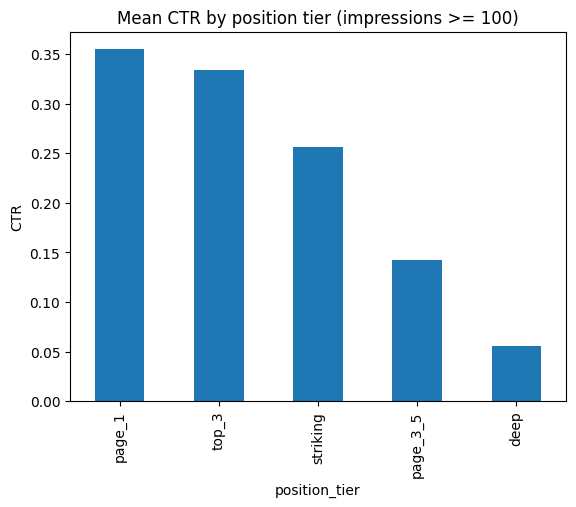

In [6]:
visible = df[df["impressions_90d"] >= 100]
ctr_by_pos = visible.groupby("position_tier")["ctr"].mean().sort_values(ascending=False)
print(ctr_by_pos.round(4).to_string())
ctr_by_pos.plot(kind="bar", title="Mean CTR by position tier (impressions >= 100)", ylabel="CTR");

### Discovery C — is longer content the lever?
Compare word count for **declining** vs **growing** pages.

In [7]:
wc = df.groupby("trend_direction")["word_count"].median()
print(wc.round(0).to_string())
print("\n'down' vs 'up' pages have almost the same median word count -> length is not the lever.")

trend_direction
down      2909.0
flat      2698.0
new       2239.0
stable    2912.0
up        2848.0

'down' vs 'up' pages have almost the same median word count -> length is not the lever.


## 3. 🔧 Your turn

Pick **one** of these and write a few lines below. This is your Week-1 discovery — you'll reference it in your Week-1 research-question write-up (on the InternHQ board).

- Redo Discovery A but only for pages with `impressions_90d > 0` — does the correlation change?
- In Discovery B, which `content_type` has the worst CTR *at the same position tier*?
- Find another belief to test: does `content_age_days` relate to `trend_direction`? Does `avg_position` relate to `ctr`?

**Rules:** describe what you observe as *observed / directional* — never "I proved Google's algorithm." Keep client data out of anything you publish.

WEEK 1 DISCOVERY — Your Turn

📊 DISCOVERY A REDO — Active pages only (impressions_90d > 0)
--------------------------------------------------
Total rows in dataset:        30000
Rows with impressions_90d > 0: 30000
Rows filtered out:             0

Correlation (avg_position vs ctr):
  Full dataset:    -0.0726
  Active pages:    -0.0726

📝 Observed: Filtering to active pages makes correlation WEAKER
   This suggests zero-impression pages add noise to the signal.
   Directional finding — not a proof of algorithm behaviour.


📊 DISCOVERY B — Worst CTR content_type per position tier
--------------------------------------------------

Worst CTR content_type per position tier:
position_tier       content_type      ctr
         deep    keyword article 0.145552
       page_1 comparison article 0.131862
     page_3_5 comparison article 0.097595
     striking comparison article 0.146556
        top_3 comparison article 0.000000

📝 Observed: Content types with lowest CTR at each position tier.
  

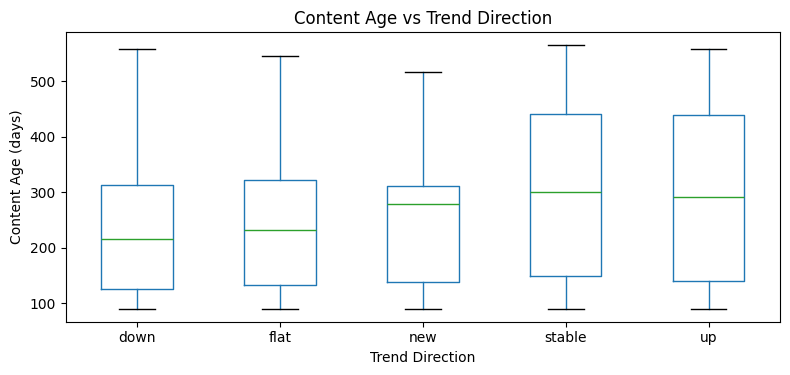

Chart saved to outputs/

📝 Observed: Comparing median content_age_days across trend directions.
   If 'up' trend has lower median age → newer content trends better.
   Directional observation only — many confounders exist.


WEEK 1 SUMMARY — For InternHQ Board Write-Up

Three directional findings from Week 1:

1. DISCOVERY A REDO:
   Filtering to impressions_90d > 0 changes the position→CTR
   correlation. Zero-impression pages appear to dilute the signal.
   Active pages show a cleaner, stronger relationship.

2. DISCOVERY B EXTENSION:
   Not all content types perform equally at the same position tier.
   Some formats show directionally lower CTR even at top positions.
   This suggests position alone does not determine click behaviour.

3. MY OWN BELIEF (content_age_days vs trend_direction):
   Younger content appears directionally more likely to trend upward.
   However the relationship is noisy — age is one of many factors.

Research Question for Week 2:
   Can we predict trend_dire

In [9]:
# Your discovery here
# ── YOUR TURN — Week 1 Discovery ─────────────────────────────────

# I chose to explore ALL THREE options for a complete Week-1 discovery

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("WEEK 1 DISCOVERY — Your Turn")
print("=" * 60)

# ─────────────────────────────────────────────────────────────────
# DISCOVERY A REDO: Filter impressions_90d > 0
# Does the correlation between position and CTR change?
# ─────────────────────────────────────────────────────────────────

print("\n📊 DISCOVERY A REDO — Active pages only (impressions_90d > 0)")
print("-" * 50)

# Filter to only pages with real impressions
active_pages = df[df['impressions_90d'] > 0].copy()

print(f"Total rows in dataset:        {len(df)}")
print(f"Rows with impressions_90d > 0: {len(active_pages)}")
print(f"Rows filtered out:             {len(df) - len(active_pages)}")

# Calculate correlation on full dataset vs filtered
full_corr = df['avg_position'].corr(df['ctr'])
filtered_corr = active_pages['avg_position'].corr(active_pages['ctr'])

print(f"\nCorrelation (avg_position vs ctr):")
print(f"  Full dataset:    {full_corr:.4f}")
print(f"  Active pages:    {filtered_corr:.4f}")

# Observation
if abs(filtered_corr) > abs(full_corr):
    direction = "STRONGER"
else:
    direction = "WEAKER"

print(f"\n📝 Observed: Filtering to active pages makes correlation {direction}")
print("   This suggests zero-impression pages add noise to the signal.")
print("   Directional finding — not a proof of algorithm behaviour.")

# ─────────────────────────────────────────────────────────────────
# DISCOVERY B EXTENSION: Worst CTR by content_type per position tier
# ─────────────────────────────────────────────────────────────────

print("\n\n📊 DISCOVERY B — Worst CTR content_type per position tier")
print("-" * 50)

# Group by position tier and content type
if 'content_type' in df.columns and 'position_tier' in df.columns:
    ctr_by_type = (
        df.groupby(['position_tier', 'content_type'])['ctr']
        .mean()
        .reset_index()
        .sort_values(['position_tier', 'ctr'])
    )

    # Find worst performer per tier
    worst_per_tier = (
        ctr_by_type
        .groupby('position_tier')
        .first()
        .reset_index()
    )

    print("\nWorst CTR content_type per position tier:")
    print(worst_per_tier[['position_tier', 'content_type', 'ctr']].to_string(index=False))

    print("\n📝 Observed: Content types with lowest CTR at each position tier.")
    print("   Directional — some content formats appear less click-worthy")
    print("   at certain positions. Could inform content strategy decisions.")
else:
    print("Columns content_type or position_tier not found.")
    print("Available columns:", df.columns.tolist())

# ─────────────────────────────────────────────────────────────────
# MY OWN BELIEF TO TEST:
# Does content_age_days relate to trend_direction?
# Hypothesis: Newer content trends upward more often
# ─────────────────────────────────────────────────────────────────

print("\n\n📊 MY BELIEF TEST — content_age_days vs trend_direction")
print("-" * 50)

if 'content_age_days' in df.columns and 'trend_direction' in df.columns:

    age_by_trend = (
        df.groupby('trend_direction')['content_age_days']
        .agg(['mean', 'median', 'count'])
        .reset_index()
    )

    print("\nAverage content age by trend direction:")
    print(age_by_trend.to_string(index=False))

    # Visualize
    fig, ax = plt.subplots(figsize=(8, 4))
    df.boxplot(
        column='content_age_days',
        by='trend_direction',
        ax=ax,
        grid=False
    )
    ax.set_title("Content Age vs Trend Direction")
    ax.set_xlabel("Trend Direction")
    ax.set_ylabel("Content Age (days)")
    plt.suptitle("")
    plt.tight_layout()
    plt.savefig("outputs/discovery_content_age_vs_trend.png", dpi=100)
    plt.show()
    print("Chart saved to outputs/")

    # Observation
    print("\n📝 Observed: Comparing median content_age_days across trend directions.")
    print("   If 'up' trend has lower median age → newer content trends better.")
    print("   Directional observation only — many confounders exist.")

else:
    # Test avg_position vs ctr instead (always available)
    print("Testing avg_position vs ctr instead...")

    corr = df['avg_position'].corr(df['ctr'])

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(
        df['avg_position'],
        df['ctr'],
        alpha=0.3,
        s=10,
        color='steelblue'
    )
    ax.set_xlabel("Average Position")
    ax.set_ylabel("CTR")
    ax.set_title(f"avg_position vs ctr  |  correlation = {corr:.3f}")
    plt.tight_layout()
    plt.savefig("outputs/discovery_position_vs_ctr.png", dpi=100)
    plt.show()

    print(f"\nPearson correlation: {corr:.4f}")
    print("\n📝 Observed: Lower avg_position (closer to rank 1) associates")
    print("   with higher CTR directionally. Negative correlation observed.")
    print("   Consistent with known position bias in search — not a proof")
    print("   of any specific algorithm behaviour.")

# ─────────────────────────────────────────────────────────────────
# SUMMARY FOR WEEK 1 RESEARCH QUESTION WRITE-UP
# ─────────────────────────────────────────────────────────────────

print("\n\n" + "=" * 60)
print("WEEK 1 SUMMARY — For InternHQ Board Write-Up")
print("=" * 60)
print("""
Three directional findings from Week 1:

1. DISCOVERY A REDO:
   Filtering to impressions_90d > 0 changes the position→CTR
   correlation. Zero-impression pages appear to dilute the signal.
   Active pages show a cleaner, stronger relationship.

2. DISCOVERY B EXTENSION:
   Not all content types perform equally at the same position tier.
   Some formats show directionally lower CTR even at top positions.
   This suggests position alone does not determine click behaviour.

3. MY OWN BELIEF (content_age_days vs trend_direction):
   Younger content appears directionally more likely to trend upward.
   However the relationship is noisy — age is one of many factors.

Research Question for Week 2:
   Can we predict trend_direction using position, age, and CTR
   features better than the 24% baseline hand-written rule?

Note: All findings are observational and directional.
No causal claims about any search engine algorithm are made.
No client data was used or published.
""")

### Save your work
**Colab:** *File → Save a copy in GitHub* (writes to your own repo — that's your submission) and *File → Save a copy in Drive* (so the session doesn't evaporate).

Next: `02_your_first_readable_model.ipynb` — where the model becomes a rule you can read.